# Поиск статей справочного центра Авито

Ноутбук воспроизводит анализ данных и проверку production-pipeline: очистку HTML, lexical query memory, Qwen3 embeddings, optional reranker и итоговый `answer.csv`. Test-разметка не используется и ответы вручную не корректируются.

In [1]:
import os
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import config
from metrics import average_precision_at_10, mean_average_precision_at_10
from retrieval import (
    build_label_matrix,
    dense_article_scores,
    dense_query_similarity,
    high_score_retrieval_scores,
    hybrid_retrieval_scores,
    leave_one_out_dense_memory_scores,
    leave_one_out_memory_scores,
    lexical_article_scores,
    lexical_query_similarity,
    load_data,
    logistic_oof_scores,
    parse_ground_truth,
    prepare_articles,
    qwen_embedding_channels,
    qwen_reranker_scores,
    rank_article_ids,
)
from solution import build_submission, save_submission, validate_submission

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)

## Данные и качество очистки HTML

In [2]:
started = perf_counter()
raw_articles, calibration, test = load_data()
articles = prepare_articles(raw_articles)
preprocessing_seconds = perf_counter() - started

article_ids = articles["article_id"].to_numpy()
ground_truth = calibration["ground_truth"].map(parse_ground_truth).tolist()
labels = build_label_matrix(calibration["ground_truth"], article_ids)

dataset_summary = pd.DataFrame(
    {
        "Набор": ["Статьи", "Calibration", "Test"],
        "Строки": [len(articles), len(calibration), len(test)],
        "Пропуски": [
            int(raw_articles.isna().sum().sum()),
            int(calibration.isna().sum().sum()),
            int(test.isna().sum().sum()),
        ],
    }
)
display(dataset_summary)
print(f"Пустых текстов после очистки: {articles.clean_body.eq('').sum()}")
print(f"Время preprocessing: {preprocessing_seconds:.2f} с")

,Набор,Строки,Пропуски
0,Статьи,793,0
1,Calibration,500,0
2,Test,500,0


Пустых текстов после очистки: 0
Время preprocessing: 4.54 с


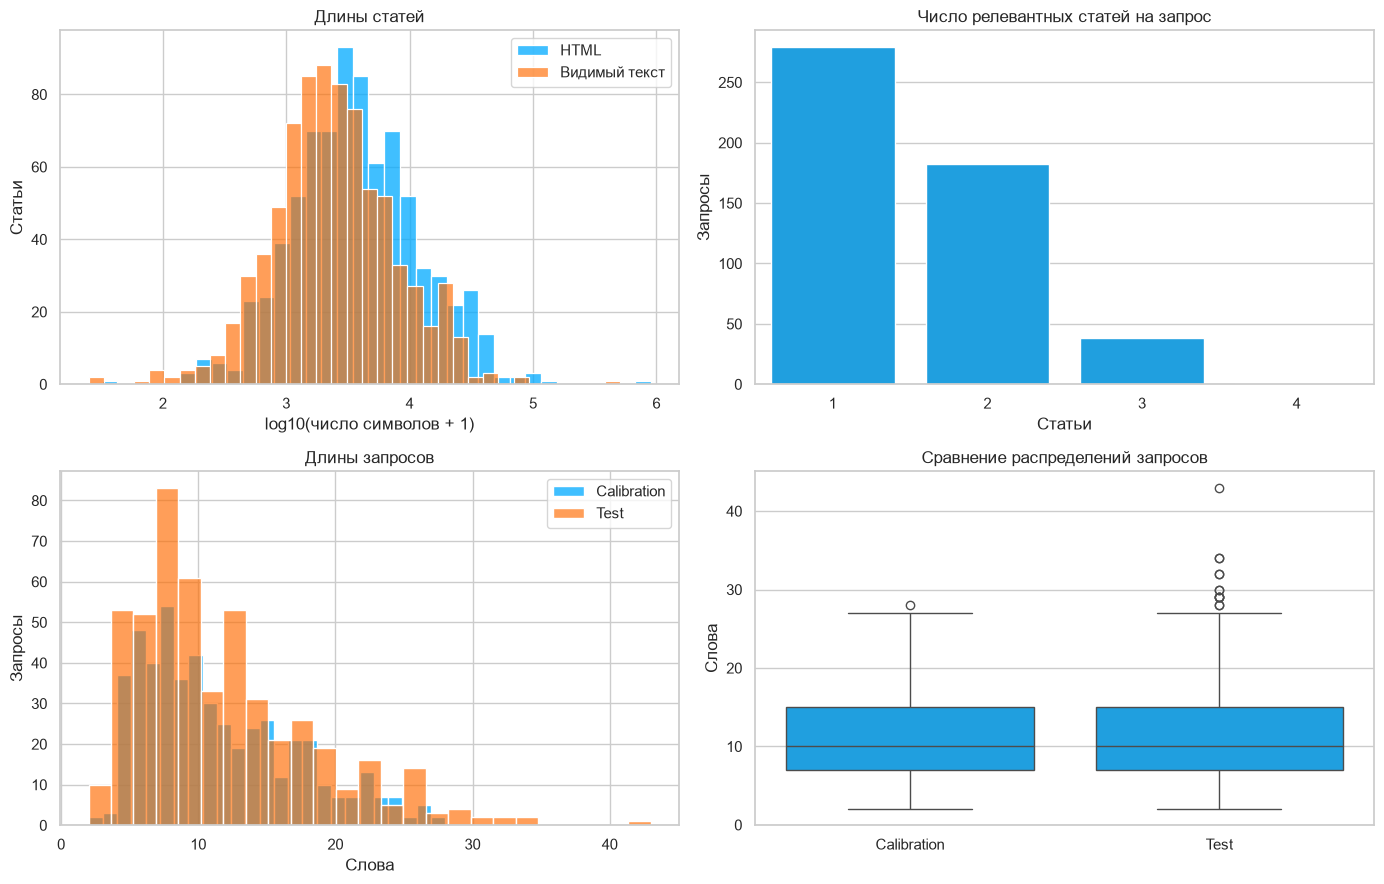

In [3]:
raw_lengths = raw_articles["body"].str.len()
visible_lengths = articles["clean_body"].str.len()
ground_truth_counts = calibration["ground_truth"].str.split().str.len()
calibration_lengths = calibration["query_text"].str.split().str.len()
test_lengths = test["query_text"].str.split().str.len()

figure, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(
    np.log10(raw_lengths + 1), bins=35, ax=axes[0, 0], color="#00AAFF", label="HTML"
)
sns.histplot(
    np.log10(visible_lengths + 1),
    bins=35,
    ax=axes[0, 0],
    color="#FF6B00",
    label="Видимый текст",
    alpha=0.65,
)
axes[0, 0].set(
    title="Длины статей", xlabel="log10(число символов + 1)", ylabel="Статьи"
)
axes[0, 0].legend()
sns.countplot(x=ground_truth_counts, ax=axes[0, 1], color="#00AAFF")
axes[0, 1].set(
    title="Число релевантных статей на запрос", xlabel="Статьи", ylabel="Запросы"
)
sns.histplot(
    calibration_lengths, bins=25, ax=axes[1, 0], color="#00AAFF", label="Calibration"
)
sns.histplot(
    test_lengths, bins=25, ax=axes[1, 0], color="#FF6B00", label="Test", alpha=0.65
)
axes[1, 0].set(title="Длины запросов", xlabel="Слова", ylabel="Запросы")
axes[1, 0].legend()
sns.boxplot(
    data=pd.DataFrame({"Calibration": calibration_lengths, "Test": test_lengths}),
    ax=axes[1, 1],
    color="#00AAFF",
)
axes[1, 1].set(title="Сравнение распределений запросов", ylabel="Слова")
figure.tight_layout()
plt.show()

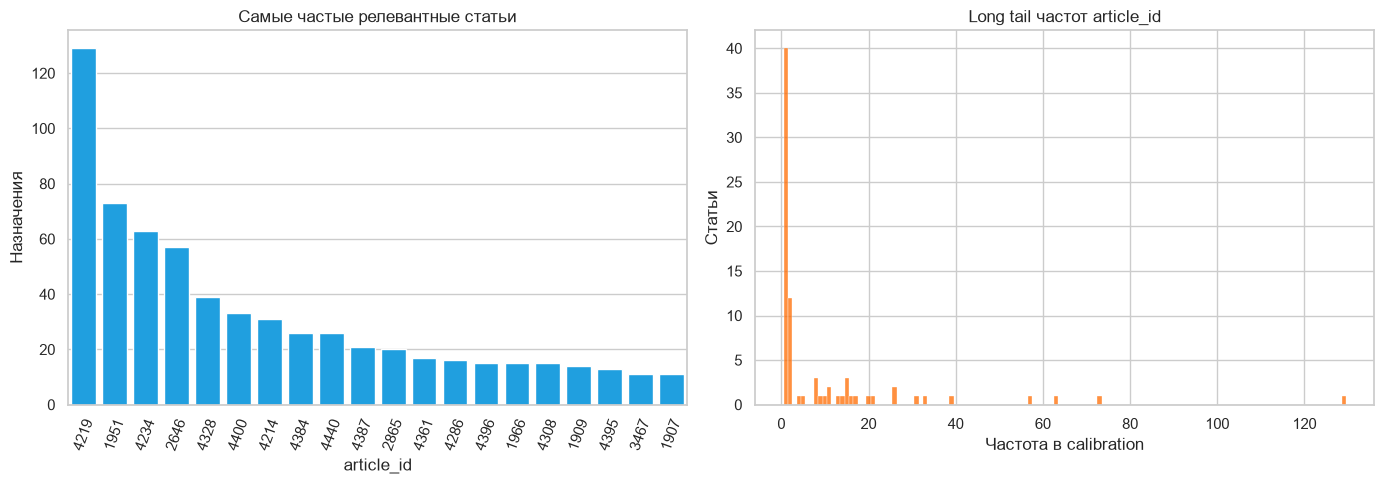

Уникальных релевантных статей: 79
Статей только с одним примером: 40


In [4]:
label_frequency = pd.Series(
    [article_id for values in ground_truth for article_id in values],
    name="article_id",
).value_counts()

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    x=label_frequency.head(20).index.astype(str),
    y=label_frequency.head(20).values,
    ax=axes[0],
    color="#00AAFF",
)
axes[0].tick_params(axis="x", rotation=70)
axes[0].set(
    title="Самые частые релевантные статьи", xlabel="article_id", ylabel="Назначения"
)
sns.histplot(label_frequency, discrete=True, ax=axes[1], color="#FF6B00")
axes[1].set(
    title="Long tail частот article_id", xlabel="Частота в calibration", ylabel="Статьи"
)
figure.tight_layout()
plt.show()
print(f"Уникальных релевантных статей: {len(label_frequency)}")
print(f"Статей только с одним примером: {(label_frequency == 1).sum()}")

## Близость запросов и validation protocol

Query memory проверяется со строгим leave-one-out. Для OOF каждый target fold исключается из переноса меток и обучения Logistic Regression.

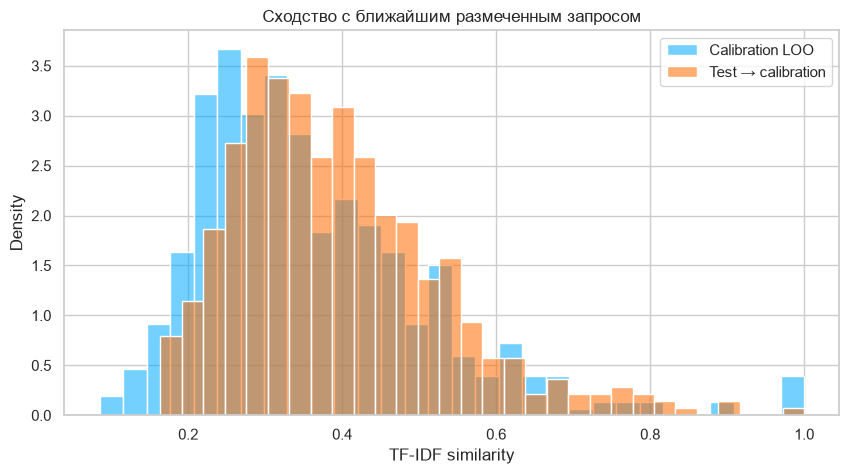

In [5]:
calibration_similarity = lexical_query_similarity(calibration["query_text"])
test_similarity = lexical_query_similarity(
    calibration["query_text"], test["query_text"]
)
nearest_calibration = calibration_similarity.max(axis=1)
nearest_test = test_similarity.max(axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(
    nearest_calibration,
    bins=30,
    stat="density",
    color="#00AAFF",
    label="Calibration LOO",
    alpha=0.55,
)
sns.histplot(
    nearest_test,
    bins=30,
    stat="density",
    color="#FF6B00",
    label="Test → calibration",
    alpha=0.55,
)
plt.title("Сходство с ближайшим размеченным запросом")
plt.xlabel("TF-IDF similarity")
plt.legend()
plt.show()

## Абляция retrieval-каналов

In [6]:
timings = {}
queries = calibration["query_text"]

started = perf_counter()
lexical_direct = lexical_article_scores(articles, queries)
lexical_memory = leave_one_out_memory_scores(calibration_similarity, labels)
classifier = logistic_oof_scores(queries, labels, config.OOF_SEEDS[1])
timings["Lexical и calibration"] = perf_counter() - started

started = perf_counter()
embedding_channels = qwen_embedding_channels(articles, queries, queries)
dense_direct = dense_article_scores(embedding_channels)
dense_similarity = dense_query_similarity(embedding_channels)
dense_memory = leave_one_out_dense_memory_scores(dense_similarity, labels)
timings["Qwen embeddings из кэша"] = perf_counter() - started

fusion = hybrid_retrieval_scores(
    lexical_direct,
    dense_direct,
    dense_memory,
    lexical_memory,
    classifier,
)

started = perf_counter()
reranker = qwen_reranker_scores(articles, queries, fusion)
high_score = high_score_retrieval_scores(fusion, reranker)
timings["Reranker из кэша"] = perf_counter() - started

score_channels = {
    "Article TF-IDF": lexical_direct,
    "Lexical query memory": lexical_memory,
    "Logistic Regression": classifier,
    "Qwen article retrieval": dense_direct,
    "Qwen query memory": dense_memory,
    "Fusion": fusion,
    "Fusion + reranker": high_score,
}
rankings = {
    name: rank_article_ids(scores, article_ids)
    for name, scores in score_channels.items()
}
ablation = pd.DataFrame(
    {
        "Подход": list(rankings),
        "MAP@10": [
            mean_average_precision_at_10(current, ground_truth)
            for current in rankings.values()
        ],
    }
).sort_values("MAP@10")
display(
    ablation.sort_values("MAP@10", ascending=False).style.format({"MAP@10": "{:.6f}"})
)

,Подход,MAP@10
6,Fusion + reranker,0.695564
5,Fusion,0.674887
4,Qwen query memory,0.654318
1,Lexical query memory,0.620102
2,Logistic Regression,0.613498
3,Qwen article retrieval,0.400998
0,Article TF-IDF,0.324200


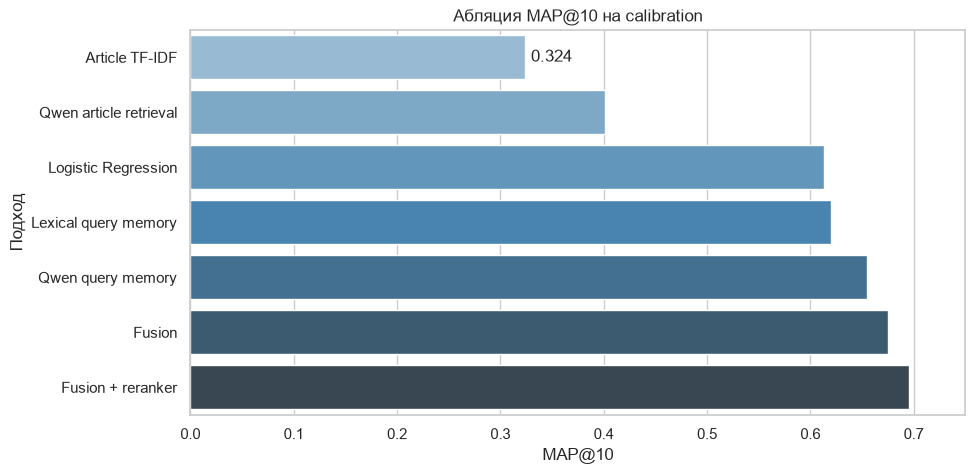

In [7]:
plt.figure(figsize=(10, 5))
axis = sns.barplot(
    data=ablation, x="MAP@10", y="Подход", hue="Подход", palette="Blues_d", legend=False
)
axis.bar_label(axis.containers[0], fmt="%.3f", padding=4)
plt.xlim(0, 0.75)
plt.title("Абляция MAP@10 на calibration")
plt.show()

## Candidate recall и срезы ошибок

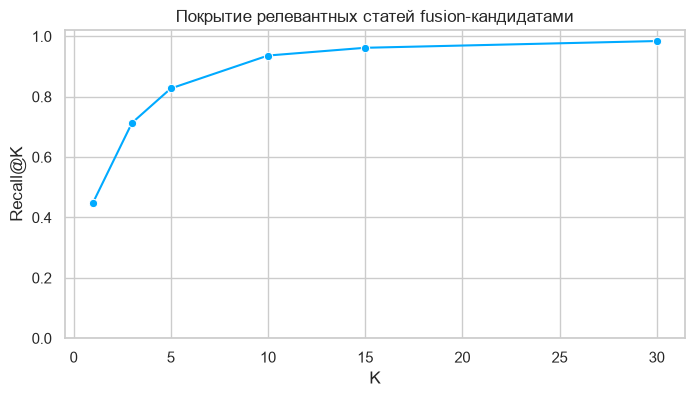

,K,Recall@K
0,1,44.950%
1,3,71.317%
2,5,82.733%
3,10,93.633%
4,15,96.200%
5,30,98.433%


In [8]:
recall_rows = []
for cutoff in (1, 3, 5, 10, 15, 30):
    current = rank_article_ids(fusion, article_ids, limit=cutoff)
    recall = np.mean(
        [
            len(set(row) & set(truth)) / len(truth)
            for row, truth in zip(current, ground_truth, strict=True)
        ]
    )
    recall_rows.append({"K": cutoff, "Recall@K": recall})

candidate_recall = pd.DataFrame(recall_rows)
plt.figure(figsize=(8, 4))
sns.lineplot(data=candidate_recall, x="K", y="Recall@K", marker="o", color="#00AAFF")
plt.ylim(0, 1.02)
plt.title("Покрытие релевантных статей fusion-кандидатами")
plt.show()
display(candidate_recall.style.format({"Recall@K": "{:.3%}"}))

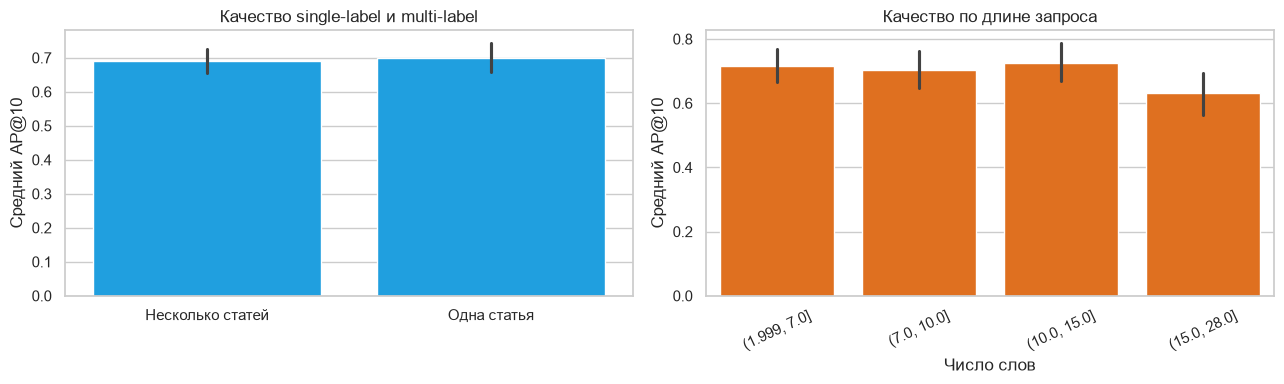

,query_id,query_text,ground_truth,prediction,AP@10
307,308,Куда опять пропал Портал призов?,4127 4321,4395 4440 4389 2646 4219 2661 2202 4273 4283 2894,0.0
324,325,"Здравствуйте, что делать, если некорректно выполнили работу, которую предоставили через Авито, взяли деньги, но пере...",4285 4332,1966 4219 4400 2646 2865 4387 4440 4234 4384 2696,0.0
10,11,"У меня была первая покупка и стоила она <MONEY> Оплата не прошла, скидка сгорела. Как вернуть оплату доставки <MONEY>?",4214,4219 4400 2646 4387 2865 1951 4384 2698 1966 4403,0.0
12,13,Пункт отправки из города Нефтекумск,4396,4328 1909 1907 4234 4286 1899 1958 4308 3467 1918,0.0
27,28,"Добрый день! Подскажите, не вижу объект в черновиках у сотрудника (Галина Светлая). В чем может быть проблема?",2661,2222 4440 2663 2904 4308 4234 2794 2886 4262 4264,0.0
51,52,Здравствуйте! Не получается оплатить за объявление балами! Что делать,4395,4440 4389 2220 2894 4384 4008 3565 2222 4219 2696,0.0
72,73,"У меня в авто теки висит ограничения на регистрацию , на автомобиль хендай салярис гос номер <ID>",4318,4423 2908 4364 4372 2914 4307 4220 4232 4361 2912,0.0
80,81,Добрый день. Разьясните пжл по брони с 10 по <DATE>. Что это за акция? Сколько мне гость при заселении должен? Там и...,3478,2095 4214 4276 4148 2707 2037 3314 4451 2721 2038,0.0
89,90,почему когда продаеш товар авито доставкой за 9999 а прийдет 8890,4361,1951 4234 4308 2646 3467 4219 3265 4214 4331 4320,0.0
186,187,"Добрый день, подскажите не получается оплатить объявление и выставить его",2222,4440 2220 4008 4389 4308 2663 2894 2942 3254 2968,0.0


In [9]:
best_rankings = rankings["Fusion + reranker"]
query_quality = calibration[["query_id", "query_text", "ground_truth"]].copy()
query_quality["gt_count"] = ground_truth_counts
query_quality["query_words"] = calibration_lengths
query_quality["AP@10"] = [
    average_precision_at_10(row, truth)
    for row, truth in zip(best_rankings, ground_truth, strict=True)
]
query_quality["prediction"] = [" ".join(map(str, row)) for row in best_rankings]
query_quality["Тип запроса"] = np.where(
    query_quality["gt_count"].eq(1), "Одна статья", "Несколько статей"
)

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=query_quality, x="Тип запроса", y="AP@10", ax=axes[0], color="#00AAFF")
axes[0].set(
    title="Качество single-label и multi-label", xlabel="", ylabel="Средний AP@10"
)
query_quality["Квартиль длины"] = pd.qcut(
    query_quality["query_words"], q=4, duplicates="drop"
)
sns.barplot(
    data=query_quality, x="Квартиль длины", y="AP@10", ax=axes[1], color="#FF6B00"
)
axes[1].tick_params(axis="x", rotation=25)
axes[1].set(
    title="Качество по длине запроса", xlabel="Число слов", ylabel="Средний AP@10"
)
figure.tight_layout()
plt.show()

display(
    query_quality.sort_values(["AP@10", "gt_count"], ascending=[True, False]).head(12)[
        ["query_id", "query_text", "ground_truth", "prediction", "AP@10"]
    ]
)

## Время и память

Fresh GPU-run измерен на RTX 3060 Laptop 6 GB. Peak VRAM получен через `torch.cuda.max_memory_allocated()` на максимальной длине и рабочих batch size; для кэшированных стадий GPU не используется.

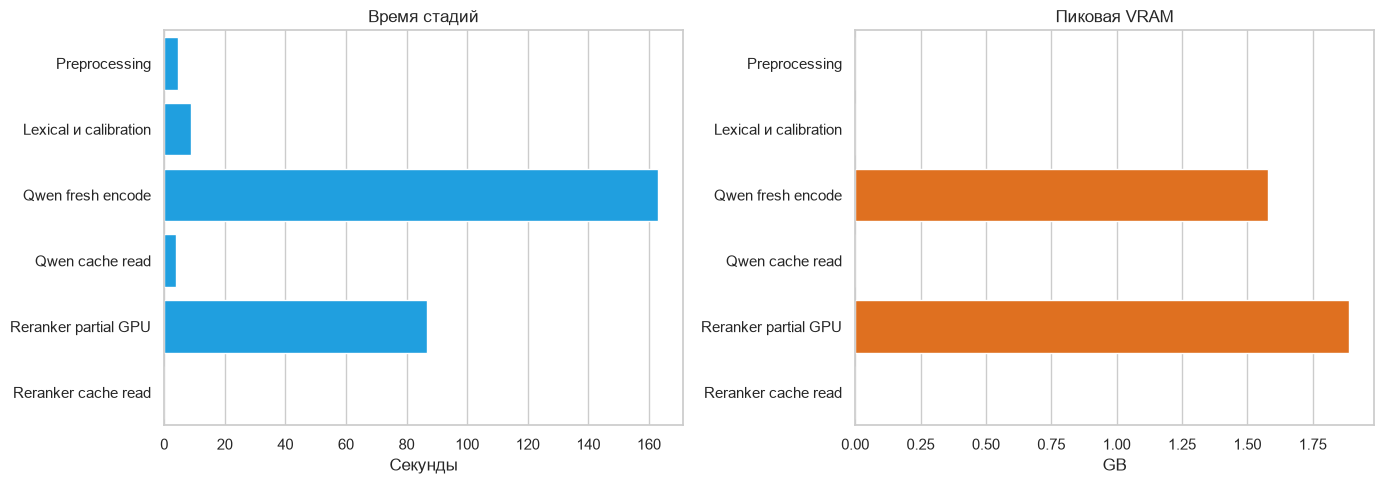

,Стадия,Секунды,"VRAM, GB"
0,Preprocessing,4.54,0.0
1,Lexical и calibration,8.72,0.0
2,Qwen fresh encode,163.10,1.6
3,Qwen cache read,3.92,0.0
4,Reranker partial GPU,86.70,1.9
5,Reranker cache read,0.05,0.0


In [10]:
runtime = pd.DataFrame(
    [
        {"Стадия": "Preprocessing", "Секунды": preprocessing_seconds, "VRAM, GB": 0.0},
        {
            "Стадия": "Lexical и calibration",
            "Секунды": timings["Lexical и calibration"],
            "VRAM, GB": 0.0,
        },
        {"Стадия": "Qwen fresh encode", "Секунды": 163.1, "VRAM, GB": 1.58},
        {
            "Стадия": "Qwen cache read",
            "Секунды": timings["Qwen embeddings из кэша"],
            "VRAM, GB": 0.0,
        },
        {"Стадия": "Reranker partial GPU", "Секунды": 86.7, "VRAM, GB": 1.89},
        {
            "Стадия": "Reranker cache read",
            "Секунды": timings["Reranker из кэша"],
            "VRAM, GB": 0.0,
        },
    ]
)
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=runtime, x="Секунды", y="Стадия", ax=axes[0], color="#00AAFF")
axes[0].set(title="Время стадий", xlabel="Секунды", ylabel="")
sns.barplot(
    data=runtime.dropna(), x="VRAM, GB", y="Стадия", ax=axes[1], color="#FF6B00"
)
axes[1].set(title="Пиковая VRAM", xlabel="GB", ylabel="")
figure.tight_layout()
plt.show()
display(runtime.style.format({"Секунды": "{:.2f}", "VRAM, GB": "{:.1f}"}))

## Итоговый submission

In [11]:
submission, test_frame, known_article_ids = build_submission(
    config.DEFAULT_DATA_DIR,
    config.HIGH_SCORE_MODE,
    config.MODEL_CACHE_DIR,
    config.DEFAULT_DEVICE,
    config.EMBEDDING_BATCH_SIZE,
)
validate_submission(submission, test_frame, known_article_ids)
submission_hash = save_submission(submission, config.DEFAULT_OUTPUT_FILE)
display(submission.head())
print(f"Строк: {len(submission)}")
print(f"SHA-256: {submission_hash}")

,query_id,answer
0,1,4396 4308 4234 4214 4219 4384 1951 2698 3467 2646
1,2,2646 2865 4219 4400 1966 4384 1958 4387 4407 4234
2,3,1909 4234 4308 4328 4396 1910 4362 4219 2646 4446
3,4,4400 4219 4234 4403 1966 2865 1951 4214 2646 4384
4,5,1951 3467 4214 4219 4308 3168 4362 2646 4532 4286


Строк: 500
SHA-256: ed3b8d18c268393c26f47b853432f283287d177c3be2b10d30ee332283cd76b9
